In [1]:
import _config
import importlib
importlib.reload(_config)
import geopandas as gpd
import requests
from shapely.geometry import shape
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Read in WF segments

In [32]:
# write out file
import os

# Split the filename and extension based on the last dot
base, extension = _config.fnWfSegments.rsplit('.', 1)

# Add '_GeoKeys' suffix to the filename part
new_filename = os.path.basename(f"{base}_GeoKeys.{extension}")

segs = 'intermediate/' + new_filename


In [33]:
# Read the shapefile
gdfSegments = gpd.read_file(segs)

In [34]:
# verify crs
print(gdfSegments.crs == _config.utmzone12n)

True


In [35]:
gdfSegments

,SEGID,BMP,EMP,DISTANCE,CO_FIPS,ROUTE,SUBAREAID,PLANAREA,DIRECTION,geometry
0,0006_141.0,141.035,146.868,5.843301,49,0006,1,MAG,EB/WB,"LINESTRING (405824.110 4423860.330, 406035.300..."
1,0006_146.9,146.868,149.902,3.039023,49,0006,1,MAG,EB/WB,"LINESTRING (413442.550 4422753.728, 413459.600..."
2,0006_149.9,149.902,150.580,0.677983,49,0006,1,MAG,EB/WB,"LINESTRING (418330.800 4422866.000, 418629.100..."
3,0006_150.6,150.580,152.555,1.973104,49,0006,1,MAG,EB/WB,"LINESTRING (419421.880 4422872.296, 419780.300..."
4,0006_152.6,152.555,152.871,0.316275,49,0006,1,MAG,EB/WB,"LINESTRING (422596.900 4422889.295, 422598.500..."
...,...,...,...,...,...,...,...,...,...,...
5475,WFRC_8489,0.000,0.000,0.505514,35,WFRC,1,WFRC,EB/WB,"LINESTRING (420577.907 4495035.704, 420598.660..."
5476,WFRC_8490,0.000,0.000,0.737896,35,WFRC,1,WFRC,EB/WB,"LINESTRING (421385.500 4495026.200, 421744.807..."
5477,WFRC_8491,0.000,0.000,0.265495,35,WFRC,1,WFRC,EB/WB,"LINESTRING (422563.717 4495144.584, 422817.227..."
5478,WFRC_8492,0.000,0.000,0.444725,35,WFRC,1,WFRC,NB/SB,"LINESTRING (423341.022 4513066.226, 423346.007..."


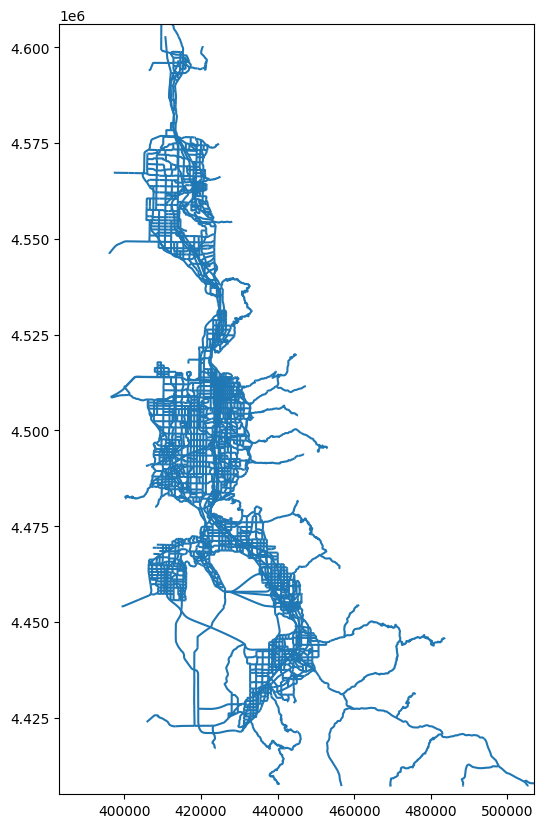

In [36]:
# Plotting
fig, ax = plt.subplots(figsize=(10, 10))
gdfSegments.plot(ax=ax)

# Normally, you would set the limits based on the UTM coordinates of your area of interest
ax.set_xlim([_config.utm_x_min, _config.utm_x_max])
ax.set_ylim([_config.utm_y_min, _config.utm_y_max])

plt.show()


# Read in UDOT AADT service

In [37]:
# The URL of the feature service
url = _config.aadtUnroundedService

# Initialize an empty list to store features
features = []

# Initialize the resultOffset
resultOffset = 0
resultRecordCount = 1000  # Adjust based on the service limit or your preference

# Loop to fetch all features
while True:
    # Parameters for fetching the data
    params = {
        'where': '1=1',  # This condition effectively means "fetch all"
        'outFields': '*',  # Fetch all fields
        'outSR': '4326',  # Specify the spatial reference (WGS84)
        'f': 'geojson',  # Get the output in GeoJSON format
        'resultOffset': resultOffset,
        'resultRecordCount': resultRecordCount
    }

    # Make the request
    response = requests.get(url, params=params)

    # Check if the request was successful
    if response.status_code == 200:
        # Convert the response to GeoJSON
        data = response.json()
        
        # Break the loop if no features are returned
        if not data['features']:
            break
        
        # Add the features to the list
        features.extend(data['features'])
        
        # Update the resultOffset to fetch the next chunk of data
        resultOffset += resultRecordCount
    else:
        print("Failed to fetch data:", response.status_code)
        break

# Convert the collected features to a GeoDataFrame
gdfAadt = gpd.GeoDataFrame.from_features(features)

# Set and reproject the CRS to UTM Zone 12N
gdfAadt = gdfAadt.set_crs('EPSG:4326', allow_override=True)
gdfAadt = gdfAadt.to_crs(epsg=_config.utmzone12n)

# Display the GeoDataFrame
display(gdfAadt)


,geometry,OBJECTID,Station,ROUTE_NAME,START_ACCU,END_ACCUM,Section_Length,DESC_,RT_NUM,AADT2023,...,SUTRK2013,CUTRK2013,SUTRK2012,CUTRK2012,SUTRK2011,CUTRK2011,SUTRK2010,CUTRK2010,RT_Type,Shape__Length
0,"LINESTRING (401742.017 4619208.393, 401767.887...",1,003-0815,1121PM,0.000,0.7638,0.7638,1000 W via 600 N - Tremont St Tremonton,1121,2015,...,0,0,0.000000,0,0,0,0,0,FA,1229.219164
1,"LINESTRING (429817.363 4471247.451, 429686.115...",2,049-0566,0089PM,350.604,351.8480,1.2440,SR 73 Lehi,89,15775,...,0.157555462,0.060798443,0.157555,0.060798443,0.157555462,0.060798443,0.157555462,0.060798443,State Route,2002.034235
2,"LINESTRING (439862.851 4464239.425, 439834.416...",3,049-0525,0089PM,342.421,342.9970,0.5760,1600 North Orem,89,46839,...,0.1205794,0.027138115,0.120579,0.027138115,0.1205794,0.027138115,0.1205794,0.027138115,State Route,926.986536
3,"LINESTRING (661779.896 4337721.445, 661792.839...",4,019-0045,0070PM,227.270,231.8541,4.5841,Westwater - Colorado State Line,70,8378,...,0.145907414,0.353843077,0.145907,0.353843077,0.145907414,0.353843077,0.145907414,0.353843077,Interstate,7377.408216
4,"LINESTRING (414890.523 4486228.831, 414890.594...",5,035-3434,0085PM,8.370,9.7160,1.3460,12600 S (Rt 2030),85,39660,...,0.0902,0.0922,0.090200,0.0922,0,0,0,0,State Route,2166.279945
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4560,"LINESTRING (268778.790 4112898.358, 268779.093...",4563,053-0433,3190PM,3.954,6.1610,2.2070,SR 18 Bluff St via Red Hills Pkwy - Skyline Dr,3190,11638,...,0,0,0.000000,0,0,0,0,0,FA,3551.830125
4561,"LINESTRING (437108.616 4468415.305, 437268.745...",4564,049-2135,2992PM,0.000,0.0995,0.0995,Jct Main Street - SR 146 via Center St in Plea...,2992,2084,...,0,0,0.000000,0,0,0,0,0,FA,160.129165
4562,"LINESTRING (440985.422 4460155.353, 440985.316...",4565,049-1705,2965PM,1.061,1.6100,0.5490,400 South via Orem Boulevard,2965,10800,...,0,0,0.000000,0,0,0,0,0,FA,883.531390
4563,"LINESTRING (431971.185 4477607.484, 431971.176...",4566,049-1851,2918PM,4.843,6.4028,1.5598,6000 W via Westfield Rd - Main St,2918,5372,...,0,0,0.000000,0,0,0,0,0,FA,2510.234657


In [38]:
gdfAadt.columns

Index(['geometry', 'OBJECTID', 'Station', 'ROUTE_NAME', 'START_ACCU',
       'END_ACCUM', 'Section_Length', 'DESC_', 'RT_NUM', 'AADT2023',
       'AADT2022', 'AADT2021', 'AADT2020', 'AADT2019', 'AADT2018', 'AADT2017',
       'AADT2016', 'AADT2015', 'AADT2014', 'AADT2013', 'AADT2012', 'AADT2011',
       'AADT2010', 'AADT2009', 'AADT2008', 'AADT2007', 'AADT2006', 'AADT2005',
       'AADT2004', 'AADT2003', 'AADT2002', 'AADT2001', 'AADT2000', 'AADT1999',
       'AADT1998', 'AADT1997', 'AADT1996', 'AADT1995', 'AADT1994', 'AADT1993',
       'AADT1992', 'AADT1991', 'AADT1990', 'AADT1989', 'AADT1988', 'AADT1987',
       'AADT1986', 'AADT1985', 'AADT1984', 'AADT1983', 'AADT1982', 'AADT1981',
       'SUTRK2023', 'CUTRK2023', 'SUTRK2022', 'CUTRK2022', 'SUTRK2021',
       'CUTRK2021', 'SUTRK2020', 'CUTRK2020', 'SUTRK2019', 'CUTRK2019',
       'SUTRK2018', 'CUTRK2018', 'SUTRK2017', 'CUTRK2017', 'SUTRK2016',
       'CUTRK2016', 'SUTRK2015', 'CUTRK2015', 'SUTRK2014', 'CUTRK2014',
       'SUTRK2013', 

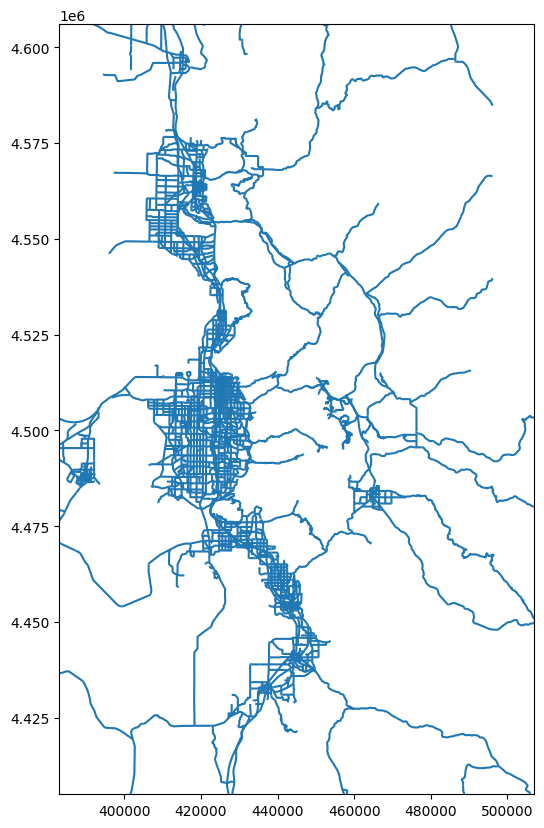

In [39]:
# Plotting
fig, ax = plt.subplots(figsize=(10, 10))
gdfAadt.plot(ax=ax)

# Normally, you would set the limits based on the UTM coordinates of your area of interest
ax.set_xlim([_config.utm_x_min, _config.utm_x_max])
ax.set_ylim([_config.utm_y_min, _config.utm_y_max])

plt.show()

# Join segments to aadt

In [40]:
# Assuming gdfSegments is your GeoDataFrame with polylines
gdfSegments['centroid_on_line'] = gdfSegments.geometry.apply(lambda x: x.interpolate(0.5, normalized=True))

# Create a GeoDataFrame from the centroids
gdfCentroids = gpd.GeoDataFrame(gdfSegments, geometry=gdfSegments['centroid_on_line'])

# Ensure both GeoDataFrames are in the same CRS
gdfCentroids = gdfCentroids.set_crs(gdfAadt.crs, allow_override=True)

# Perform the spatial join with gdfAadt to find the nearest feature # max distance 3 meters
gdfJoined = gpd.sjoin_nearest(gdfCentroids, gdfAadt, how="left", distance_col="join_distance", max_distance=_config.maxjoindistance)

gdfJoined.fillna(0, inplace=True)

display(gdfJoined)

,SEGID,BMP,EMP,DISTANCE,CO_FIPS,ROUTE,SUBAREAID,PLANAREA,DIRECTION,geometry,...,CUTRK2013,SUTRK2012,CUTRK2012,SUTRK2011,CUTRK2011,SUTRK2010,CUTRK2010,RT_Type,Shape__Length,join_distance
0,0006_141.0,141.035,146.868,5.843301,49,0006,1,MAG,EB/WB,POINT (409517.047 4424943.556),...,0.060300209,0.078625,0.066644806,0.076659734,0.063559876,0.090717089,0.052861231,State Route,14331.237256,0.354355
1,0006_146.9,146.868,149.902,3.039023,49,0006,1,MAG,EB/WB,POINT (415885.441 4422851.050),...,0.060300209,0.078625,0.066644806,0.076659734,0.063559876,0.090717089,0.052861231,State Route,14331.237256,0.672016
2,0006_149.9,149.902,150.580,0.677983,49,0006,1,MAG,EB/WB,POINT (418876.352 4422867.232),...,0.092806024,0.116361,0.095978323,0.115378418,0.094435858,0.122407096,0.089086536,State Route,4266.379040,0.674937
3,0006_150.6,150.580,152.555,1.973104,49,0006,1,MAG,EB/WB,POINT (421009.462 4422885.520),...,0.092806024,0.116361,0.095978323,0.115378418,0.094435858,0.122407096,0.089086536,State Route,4266.379040,0.669957
4,0006_152.6,152.555,152.871,0.316275,49,0006,1,MAG,EB/WB,POINT (422849.414 4422918.278),...,0.12531184,0.154097,0.12531184,0.154097102,0.12531184,0.154097102,0.12531184,State Route,505.334907,0.672275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5475,WFRC_8489,0.000,0.000,0.505514,35,WFRC,1,WFRC,EB/WB,POINT (420982.215 4495018.677),...,0,0.000000,0,0,0,0,0,0,0.000000,0.000000
5476,WFRC_8490,0.000,0.000,0.737896,35,WFRC,1,WFRC,EB/WB,POINT (421976.073 4495063.345),...,0,0.000000,0,0,0,0,0,0,0.000000,0.000000
5477,WFRC_8491,0.000,0.000,0.265495,35,WFRC,1,WFRC,EB/WB,POINT (422777.119 4495154.593),...,0,0.000000,0,0,0,0,0,0,0.000000,0.000000
5478,WFRC_8492,0.000,0.000,0.444725,35,WFRC,1,WFRC,NB/SB,POINT (423347.215 4513424.027),...,0,0.000000,0,0,0,0,0,0,0.000000,0.000000


In [41]:
gdfJoined.columns

Index(['SEGID', 'BMP', 'EMP', 'DISTANCE', 'CO_FIPS', 'ROUTE', 'SUBAREAID',
       'PLANAREA', 'DIRECTION', 'geometry', 'centroid_on_line', 'index_right',
       'OBJECTID', 'Station', 'ROUTE_NAME', 'START_ACCU', 'END_ACCUM',
       'Section_Length', 'DESC_', 'RT_NUM', 'AADT2023', 'AADT2022', 'AADT2021',
       'AADT2020', 'AADT2019', 'AADT2018', 'AADT2017', 'AADT2016', 'AADT2015',
       'AADT2014', 'AADT2013', 'AADT2012', 'AADT2011', 'AADT2010', 'AADT2009',
       'AADT2008', 'AADT2007', 'AADT2006', 'AADT2005', 'AADT2004', 'AADT2003',
       'AADT2002', 'AADT2001', 'AADT2000', 'AADT1999', 'AADT1998', 'AADT1997',
       'AADT1996', 'AADT1995', 'AADT1994', 'AADT1993', 'AADT1992', 'AADT1991',
       'AADT1990', 'AADT1989', 'AADT1988', 'AADT1987', 'AADT1986', 'AADT1985',
       'AADT1984', 'AADT1983', 'AADT1982', 'AADT1981', 'SUTRK2023',
       'CUTRK2023', 'SUTRK2022', 'CUTRK2022', 'SUTRK2021', 'CUTRK2021',
       'SUTRK2020', 'CUTRK2020', 'SUTRK2019', 'CUTRK2019', 'SUTRK2018',
       'C

# CHECK NAs

In [42]:
# HAVE TO TURN OFF FILL NA FOR THIS TO DO ANYTHING
gdfJoined[(gdfJoined[['join_distance']].isnull().any(axis=1)) & ~(gdfJoined['ROUTE'].isin(['MAG','UTA','WFRC']))]


,SEGID,BMP,EMP,DISTANCE,CO_FIPS,ROUTE,SUBAREAID,PLANAREA,DIRECTION,geometry,...,CUTRK2013,SUTRK2012,CUTRK2012,SUTRK2011,CUTRK2011,SUTRK2010,CUTRK2010,RT_Type,Shape__Length,join_distance


In [43]:


# Step 2 and 3: Group by the new column and calculate the max distance for each group
max_distance_by_group = gdfJoined.groupby('ROUTE')['join_distance'].max()

# Display the result
print(max_distance_by_group)


ROUTE
0006    1.172321
0013    1.002616
0015    1.193857
0026    1.196865
0037    1.004670
          ...   
3466    0.445570
3470    1.004371
MAG     1.189045
UTA     0.000000
WFRC    1.086333
Name: join_distance, Length: 712, dtype: float64


In [44]:
gdfJoined[(gdfJoined['ROUTE'].isin(['MAG','WFRC','UTA'])) & (gdfJoined['join_distance']>0)][['SEGID','join_distance']]

,SEGID,join_distance
4106,MAG_6017,0.991437
4110,MAG_6021,1.189045
4146,MAG_6067,1.164910
4148,MAG_6069,0.663417
4215,MAG_6139,0.690594
4653,MAG_6604,0.662623
5029,WFRC_8004,0.999204
5034,WFRC_8010,0.661483
5214,WFRC_8220,0.884933
5253,WFRC_8262,0.990772


# check non-planning segs to see those with distance .75 * the maxjoindistance

In [45]:
gdfJoined

,SEGID,BMP,EMP,DISTANCE,CO_FIPS,ROUTE,SUBAREAID,PLANAREA,DIRECTION,geometry,...,CUTRK2013,SUTRK2012,CUTRK2012,SUTRK2011,CUTRK2011,SUTRK2010,CUTRK2010,RT_Type,Shape__Length,join_distance
0,0006_141.0,141.035,146.868,5.843301,49,0006,1,MAG,EB/WB,POINT (409517.047 4424943.556),...,0.060300209,0.078625,0.066644806,0.076659734,0.063559876,0.090717089,0.052861231,State Route,14331.237256,0.354355
1,0006_146.9,146.868,149.902,3.039023,49,0006,1,MAG,EB/WB,POINT (415885.441 4422851.050),...,0.060300209,0.078625,0.066644806,0.076659734,0.063559876,0.090717089,0.052861231,State Route,14331.237256,0.672016
2,0006_149.9,149.902,150.580,0.677983,49,0006,1,MAG,EB/WB,POINT (418876.352 4422867.232),...,0.092806024,0.116361,0.095978323,0.115378418,0.094435858,0.122407096,0.089086536,State Route,4266.379040,0.674937
3,0006_150.6,150.580,152.555,1.973104,49,0006,1,MAG,EB/WB,POINT (421009.462 4422885.520),...,0.092806024,0.116361,0.095978323,0.115378418,0.094435858,0.122407096,0.089086536,State Route,4266.379040,0.669957
4,0006_152.6,152.555,152.871,0.316275,49,0006,1,MAG,EB/WB,POINT (422849.414 4422918.278),...,0.12531184,0.154097,0.12531184,0.154097102,0.12531184,0.154097102,0.12531184,State Route,505.334907,0.672275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5475,WFRC_8489,0.000,0.000,0.505514,35,WFRC,1,WFRC,EB/WB,POINT (420982.215 4495018.677),...,0,0.000000,0,0,0,0,0,0,0.000000,0.000000
5476,WFRC_8490,0.000,0.000,0.737896,35,WFRC,1,WFRC,EB/WB,POINT (421976.073 4495063.345),...,0,0.000000,0,0,0,0,0,0,0.000000,0.000000
5477,WFRC_8491,0.000,0.000,0.265495,35,WFRC,1,WFRC,EB/WB,POINT (422777.119 4495154.593),...,0,0.000000,0,0,0,0,0,0,0.000000,0.000000
5478,WFRC_8492,0.000,0.000,0.444725,35,WFRC,1,WFRC,NB/SB,POINT (423347.215 4513424.027),...,0,0.000000,0,0,0,0,0,0,0.000000,0.000000


In [46]:
gdfJoined[(~gdfJoined['ROUTE'].isin(['MAG','WFRC','UTA'])) & (gdfJoined['join_distance']>_config.maxjoindistance*.75)][['SEGID','join_distance']]

,SEGID,join_distance


# Prep final shapefile

In [48]:
# drop unneeded columns
gdfJoined_AdjCols = gdfJoined.copy()
gdfJoined_AdjCols.drop(columns=['geometry', 'BMP', 'EMP', 'DISTANCE', 'geometry', 'centroid_on_line', 'index_right', 'OBJECTID', 'ROUTE_NAME', 'START_ACCU', 'END_ACCUM', 'DESC_', 'RT_NUM', 'RT_Type', 'join_distance'], inplace=True)
gdfJoined_AdjCols.rename(columns={'Station':'AADTSTN'}, inplace=True)
gdfJoined_AdjCols.columns

Index(['SEGID', 'CO_FIPS', 'ROUTE', 'SUBAREAID', 'PLANAREA', 'DIRECTION',
       'AADTSTN', 'Section_Length', 'AADT2023', 'AADT2022', 'AADT2021',
       'AADT2020', 'AADT2019', 'AADT2018', 'AADT2017', 'AADT2016', 'AADT2015',
       'AADT2014', 'AADT2013', 'AADT2012', 'AADT2011', 'AADT2010', 'AADT2009',
       'AADT2008', 'AADT2007', 'AADT2006', 'AADT2005', 'AADT2004', 'AADT2003',
       'AADT2002', 'AADT2001', 'AADT2000', 'AADT1999', 'AADT1998', 'AADT1997',
       'AADT1996', 'AADT1995', 'AADT1994', 'AADT1993', 'AADT1992', 'AADT1991',
       'AADT1990', 'AADT1989', 'AADT1988', 'AADT1987', 'AADT1986', 'AADT1985',
       'AADT1984', 'AADT1983', 'AADT1982', 'AADT1981', 'SUTRK2023',
       'CUTRK2023', 'SUTRK2022', 'CUTRK2022', 'SUTRK2021', 'CUTRK2021',
       'SUTRK2020', 'CUTRK2020', 'SUTRK2019', 'CUTRK2019', 'SUTRK2018',
       'CUTRK2018', 'SUTRK2017', 'CUTRK2017', 'SUTRK2016', 'CUTRK2016',
       'SUTRK2015', 'CUTRK2015', 'SUTRK2014', 'CUTRK2014', 'SUTRK2013',
       'CUTRK2013', 'SUT

In [49]:
# Assuming 'segs' is the path to your shapefile and 'gdfJoined' is already defined
gdfSegments = gpd.read_file(_config.fnWfSegments)

# Perform the join
# It's more conventional to call merge directly on the DataFrame or GeoDataFrame object
gdfSegmentsWithAADT = gdfSegments.merge(gdfJoined_AdjCols, on='SEGID', how='left')

# Set the geometry column
# Assuming 'geometry' is the name of the column in 'gdfSegmentsWithAADT' you want to use as geometry
# This step also ensures 'gdfSegmentsWithAADT' is treated as a GeoDataFrame
gdfSegmentsWithAADT = gpd.GeoDataFrame(gdfSegmentsWithAADT, geometry='geometry')
gdfSegmentsWithAADT

,SEGID,BMP,EMP,DISTANCE,geometry,CO_FIPS,ROUTE,SUBAREAID,PLANAREA,DIRECTION,...,CUTRK2014,SUTRK2013,CUTRK2013,SUTRK2012,CUTRK2012,SUTRK2011,CUTRK2011,SUTRK2010,CUTRK2010,Shape__Length
0,0006_141.0,141.035,146.868,5.843301,"LINESTRING (405824.110 4423860.330, 406035.300...",49,0006,1,MAG,EB/WB,...,0.063092907,0.069628124,0.060300209,0.078625,0.066644806,0.076659734,0.063559876,0.090717089,0.052861231,14331.237256
1,0006_146.9,146.868,149.902,3.039023,"LINESTRING (413442.550 4422753.728, 413459.600...",49,0006,1,MAG,EB/WB,...,0.063092907,0.069628124,0.060300209,0.078625,0.066644806,0.076659734,0.063559876,0.090717089,0.052861231,14331.237256
2,0006_149.9,149.902,150.580,0.677983,"LINESTRING (418330.800 4422866.000, 418629.100...",49,0006,1,MAG,EB/WB,...,0.094202374,0.111862613,0.092806024,0.116361,0.095978323,0.115378418,0.094435858,0.122407096,0.089086536,4266.379040
3,0006_150.6,150.580,152.555,1.973104,"LINESTRING (419421.880 4422872.296, 419780.300...",49,0006,1,MAG,EB/WB,...,0.094202374,0.111862613,0.092806024,0.116361,0.095978323,0.115378418,0.094435858,0.122407096,0.089086536,4266.379040
4,0006_152.6,152.555,152.871,0.316275,"LINESTRING (422596.900 4422889.295, 422598.500...",49,0006,1,MAG,EB/WB,...,0.12531184,0.154097102,0.12531184,0.154097,0.12531184,0.154097102,0.12531184,0.154097102,0.12531184,505.334907
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5475,WFRC_8489,0.000,0.000,0.505514,"LINESTRING (420577.907 4495035.704, 420598.660...",35,WFRC,1,WFRC,EB/WB,...,0,0,0,0.000000,0,0,0,0,0,0.000000
5476,WFRC_8490,0.000,0.000,0.737896,"LINESTRING (421385.500 4495026.200, 421744.807...",35,WFRC,1,WFRC,EB/WB,...,0,0,0,0.000000,0,0,0,0,0,0.000000
5477,WFRC_8491,0.000,0.000,0.265495,"LINESTRING (422563.717 4495144.584, 422817.227...",35,WFRC,1,WFRC,EB/WB,...,0,0,0,0.000000,0,0,0,0,0,0.000000
5478,WFRC_8492,0.000,0.000,0.444725,"LINESTRING (423341.022 4513066.226, 423346.007...",35,WFRC,1,WFRC,NB/SB,...,0,0,0,0.000000,0,0,0,0,0,0.000000


In [50]:
# Get a list of all column names except 'geometry'
cols = [col for col in gdfSegmentsWithAADT.columns if col != 'geometry']

# Add 'geometry' back to the end of the list
cols.append('geometry')

# Reorder the DataFrame by selecting the columns in the new order
gdfSegmentsWithAADT = gdfSegmentsWithAADT[cols]

# Now, the 'geometry' column should be the last column in the DataFrame
gdfSegmentsWithAADT

,SEGID,BMP,EMP,DISTANCE,CO_FIPS,ROUTE,SUBAREAID,PLANAREA,DIRECTION,AADTSTN,...,SUTRK2013,CUTRK2013,SUTRK2012,CUTRK2012,SUTRK2011,CUTRK2011,SUTRK2010,CUTRK2010,Shape__Length,geometry
0,0006_141.0,141.035,146.868,5.843301,49,0006,1,MAG,EB/WB,049-0005,...,0.069628124,0.060300209,0.078625,0.066644806,0.076659734,0.063559876,0.090717089,0.052861231,14331.237256,"LINESTRING (405824.110 4423860.330, 406035.300..."
1,0006_146.9,146.868,149.902,3.039023,49,0006,1,MAG,EB/WB,049-0005,...,0.069628124,0.060300209,0.078625,0.066644806,0.076659734,0.063559876,0.090717089,0.052861231,14331.237256,"LINESTRING (413442.550 4422753.728, 413459.600..."
2,0006_149.9,149.902,150.580,0.677983,49,0006,1,MAG,EB/WB,049-0010,...,0.111862613,0.092806024,0.116361,0.095978323,0.115378418,0.094435858,0.122407096,0.089086536,4266.379040,"LINESTRING (418330.800 4422866.000, 418629.100..."
3,0006_150.6,150.580,152.555,1.973104,49,0006,1,MAG,EB/WB,049-0010,...,0.111862613,0.092806024,0.116361,0.095978323,0.115378418,0.094435858,0.122407096,0.089086536,4266.379040,"LINESTRING (419421.880 4422872.296, 419780.300..."
4,0006_152.6,152.555,152.871,0.316275,49,0006,1,MAG,EB/WB,049-0011,...,0.154097102,0.12531184,0.154097,0.12531184,0.154097102,0.12531184,0.154097102,0.12531184,505.334907,"LINESTRING (422596.900 4422889.295, 422598.500..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5475,WFRC_8489,0.000,0.000,0.505514,35,WFRC,1,WFRC,EB/WB,0,...,0,0,0.000000,0,0,0,0,0,0.000000,"LINESTRING (420577.907 4495035.704, 420598.660..."
5476,WFRC_8490,0.000,0.000,0.737896,35,WFRC,1,WFRC,EB/WB,0,...,0,0,0.000000,0,0,0,0,0,0.000000,"LINESTRING (421385.500 4495026.200, 421744.807..."
5477,WFRC_8491,0.000,0.000,0.265495,35,WFRC,1,WFRC,EB/WB,0,...,0,0,0.000000,0,0,0,0,0,0.000000,"LINESTRING (422563.717 4495144.584, 422817.227..."
5478,WFRC_8492,0.000,0.000,0.444725,35,WFRC,1,WFRC,NB/SB,0,...,0,0,0.000000,0,0,0,0,0,0.000000,"LINESTRING (423341.022 4513066.226, 423346.007..."


In [51]:
gdfJoined[gdfJoined['SEGID']=='0067_004.0']


,SEGID,BMP,EMP,DISTANCE,CO_FIPS,ROUTE,SUBAREAID,PLANAREA,DIRECTION,geometry,...,CUTRK2013,SUTRK2012,CUTRK2012,SUTRK2011,CUTRK2011,SUTRK2010,CUTRK2010,RT_Type,Shape__Length,join_distance
230,0067_004.0,3.999,4.03,0.369729,11,0067,1,WFRC,EB/WB,POINT (421346.139 4526296.819),...,0,0.0,0,0,0,0,0,0,0.0,0.0


In [52]:
# write out file
import os

# Split the filename and extension based on the last dot
base, extension = segs.rsplit('.', 1)

# Add '_GeoKeys' suffix to the filename part
new_filename = os.path.basename(f"{base}_AADTs.{extension}")

gdfSegmentsWithAADT.to_file('intermediate/' + new_filename)
print('Exported: intermediate/' + new_filename)
print("Done!")

C:\Users\cday\AppData\Local\Temp\ipykernel_36500\3320755061.py:10: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdfSegmentsWithAADT.to_file('intermediate/' + new_filename)


Exported: intermediate/WFv910_Segments_GeoKeys_AADTs.shp
Done!
